# Feature Engineering + Pipeline

Коротко: создаём компактный набор признаков, убираем утечки и проверяем пайплайн RandomForest.


## Setup / Настройка


In [1]:
# База / core
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_openml

# Sklearn / ML
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Корень проекта / project root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())

# Стиль / style
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 70)
plt.rcParams["figure.figsize"] = (8, 4)


In [2]:
# Данные как в задании / data as in the task
# fetch_openml("titanic", version=1, as_frame=True).frame
df = fetch_openml("titanic", version=1, as_frame=True).frame
y = df["survived"].astype(int)  # таргет / target

print(f"shape: {df.shape}")
df.head()


shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Feature Engineering / Создание признаков


In [3]:
# FE-функции / FE functions

def add_family_features(data: pd.DataFrame) -> pd.DataFrame:
    """Семья и цена / family & fare."""
    d = data.copy()
    d["FamilySize"] = d["sibsp"] + d["parch"] + 1
    d["IsAlone"] = (d["FamilySize"] == 1).astype(int)
    d["FamilyGroup"] = pd.cut(
        d["FamilySize"],
        bins=[0, 1, 4, 7, np.inf],
        labels=["single", "small", "medium", "large"],
    )
    d["FarePerPerson"] = d["fare"] / d["FamilySize"]
    d["FemaleWithChildren"] = ((d["sex"] == "female") & (d["FamilySize"] > 1)).astype(int)
    return d


def add_name_features(data: pd.DataFrame) -> pd.DataFrame:
    """Фамилия и титул / surname & title."""
    d = data.copy()

    # Настройки титулов / title settings
    title_replace = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
    rare_titles = [
        "Lady", "Countess", "Capt", "Col", "Don", "Dr",
        "Major", "Rev", "Sir", "Jonkheer", "Dona",
    ]

    d["Surname"] = d["name"].str.split(",").str[0]
    d["Title"] = d["name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
    d["Title"] = d["Title"].replace(title_replace).replace(rare_titles, "Rare")
    return d


def add_ticket_features(data: pd.DataFrame) -> pd.DataFrame:
    """Группа и префикс билета / ticket group & prefix."""
    d = data.copy()
    d["TicketCount"] = d.groupby("ticket")["ticket"].transform("count")
    d["SharedTicket"] = (d["TicketCount"] > 1).astype(int)

    prefix = (
        d["ticket"].astype(str)
        .str.replace(r"\d+", "", regex=True)
        .str.replace(".", "", regex=False)
        .str.replace("/", "", regex=False)
        .str.strip()
        .replace("", "NONE")
    )
    counts = prefix.value_counts()
    d["TicketPrefix"] = prefix.where(prefix.map(counts) >= 10, "Rare")
    return d


def add_cabin_features(data: pd.DataFrame) -> pd.DataFrame:
    """Каюта / cabin."""
    d = data.copy()
    d["HasCabin"] = d["cabin"].notna().astype(int)
    d["CabinLetter"] = d["cabin"].str[0]
    return d


def add_age_features(data: pd.DataFrame) -> pd.DataFrame:
    """Возраст / age."""
    d = data.copy()
    d["AgeGroup"] = pd.cut(
        d["age"],
        bins=[0, 16, 30, 60, np.inf],
        labels=["child", "young", "adult", "senior"],
    )
    d["Child"] = np.where(d["age"].isna(), np.nan, (d["age"] < 16).astype(int))
    return d


def add_interaction_features(data: pd.DataFrame) -> pd.DataFrame:
    """Простые склейки / simple interactions."""
    d = data.copy()
    child_type = np.select(
        [d["Child"] == 1, d["Child"] == 0],
        ["child", "adult"],
        default="unknown",
    )
    d["SexPclass"] = d["sex"].astype(str) + "_" + d["pclass"].astype(str)
    d["TitlePclass"] = d["Title"].astype(str) + "_" + d["pclass"].astype(str)
    d["ChildPclass"] = pd.Series(child_type, index=d.index) + "_" + d["pclass"].astype(str)
    return d


def create_features(data: pd.DataFrame) -> pd.DataFrame:
    """Все FE-шаги / all FE steps."""
    d = add_family_features(data)
    d = add_name_features(d)
    d = add_ticket_features(d)
    d = add_cabin_features(d)
    d = add_age_features(d)
    return add_interaction_features(d)


In [4]:
# Новые признаки / new features
df_fe = create_features(df)
new_features = sorted(set(df_fe.columns) - set(df.columns))

print(f"before FE: {df.shape[1]}")
print(f"after FE : {df_fe.shape[1]}")
print(f"new      : {len(new_features)}")
display(pd.Series(new_features, name="new_features").to_frame())


before FE: 14
after FE : 31
new      : 17


,new_features
0,AgeGroup
1,CabinLetter
2,Child
3,ChildPclass
4,FamilyGroup
5,FamilySize
6,FarePerPerson
7,FemaleWithChildren
8,HasCabin
9,IsAlone


## Quick Checks / Быстрые проверки


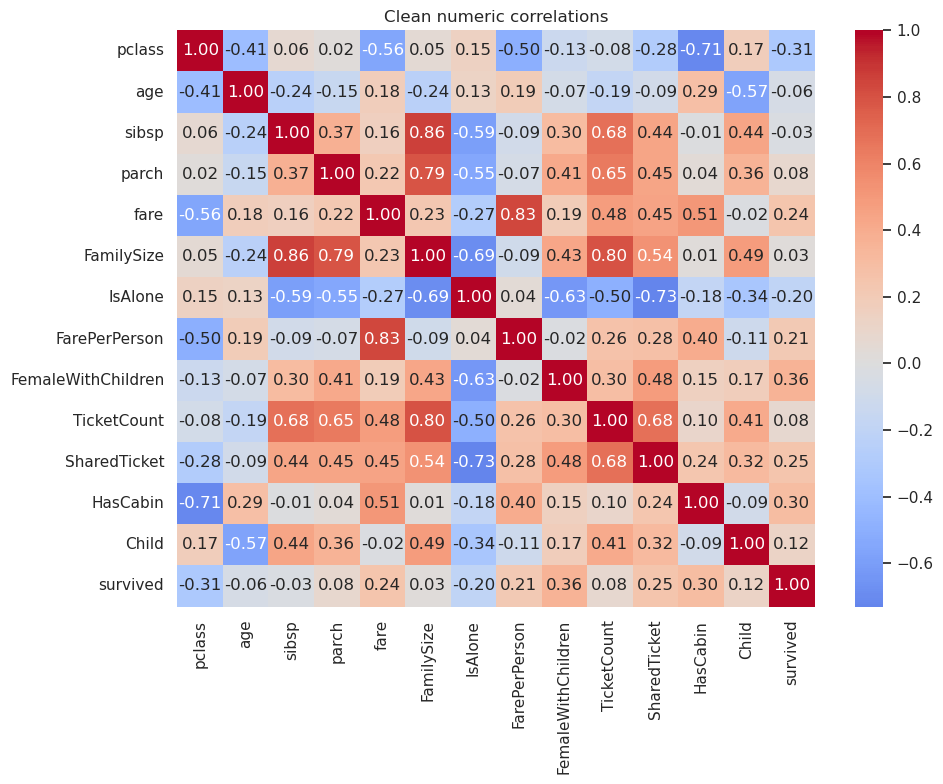

In [5]:
# Корреляции честных числовых / clean numeric correlations
LEAKAGE_COLUMNS = ["boat", "body", "home.dest"]
raw_text_columns = ["name", "ticket", "cabin", "Surname"]

corr_df = (
    df_fe
    .drop(columns=LEAKAGE_COLUMNS + raw_text_columns, errors="ignore")
    .select_dtypes(include="number")
    .assign(survived=y)
)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Clean numeric correlations")
plt.tight_layout()
plt.show()


In [6]:
# Кардинальность категорий / categorical cardinality
cat_cardinality = (
    df_fe.select_dtypes(include=["object", "category"])
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .to_frame("n_unique")
)
display(cat_cardinality)


/tmp/ipykernel_38065/1261293829.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_fe.select_dtypes(include=["object", "category"])


,n_unique
name,1307
ticket,929
Surname,875
home.dest,370
cabin,187
boat,28
TitlePclass,15
ChildPclass,9
CabinLetter,9
TicketPrefix,9


## Clean Dataset / Чистый датасет


In [7]:
# Убираем утечки и сырые текстовые поля / drop leakage & raw text
DROP_COLUMNS = [
    "boat",       # утечка / leakage
    "body",       # утечка / leakage
    "home.dest",  # шумно / noisy
    "name",       # уже извлекли / already extracted
    "ticket",     # уже извлекли / already extracted
    "cabin",      # уже извлекли / already extracted
    "Surname",    # высокая кардинальность / high cardinality
]

df_model = df_fe.drop(columns=DROP_COLUMNS)
print(f"model columns: {df_model.shape[1]}")
display(pd.Series(df_model.columns, name="columns").to_frame())


model columns: 24


,columns
0,pclass
1,survived
2,sex
3,age
4,sibsp
5,parch
6,fare
7,embarked
8,FamilySize
9,IsAlone


In [8]:
# Пропуски / missing
missing = df_model.isna().mean().mul(100).sort_values(ascending=False)
display(missing[missing > 0].round(1).to_frame("missing_%"))


,missing_%
CabinLetter,77.5
age,20.1
AgeGroup,20.1
Child,20.1
embarked,0.2
FarePerPerson,0.1
fare,0.1


## Train/Test Split / Разбиение


In [9]:
# X/y и split / features, target & split
X = df_model.drop(columns="survived")
y = df_model["survived"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("train:", X_train.shape, y_train.shape)
print("test :", X_test.shape, y_test.shape)


train: (1047, 23) (1047,)
test : (262, 23) (262,)


In [10]:
# Типы признаков / feature types
numeric_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("numeric:", numeric_features)
print("categorical:", categorical_features)


numeric: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'FemaleWithChildren', 'TicketCount', 'SharedTicket', 'HasCabin', 'Child']
categorical: ['sex', 'embarked', 'FamilyGroup', 'Title', 'TicketPrefix', 'CabinLetter', 'AgeGroup', 'SexPclass', 'TitlePclass', 'ChildPclass']


## Pipeline / Пайплайн


In [11]:
# Preprocessor / препроцессинг
def make_preprocessor(num_cols, cat_cols):
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])


def make_model(estimator, num_cols=numeric_features, cat_cols=categorical_features):
    return Pipeline([
        ("preprocessor", make_preprocessor(num_cols, cat_cols)),
        ("model", estimator),
    ])


def evaluate(model, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test, cv=5):
    """CV + test accuracy / оценка модели."""
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"CV accuracy  : {scores.mean():.4f} ± {scores.std():.4f}")
    print(f"Test accuracy: {test_acc:.4f}")
    return scores, test_acc


In [12]:
# Базовый RF / default random forest
rf_default = RandomForestClassifier(random_state=42, n_jobs=-1)
model_default = make_model(rf_default)

scores_default, acc_default = evaluate(model_default)


CV accuracy  : 0.7908 ± 0.0204
Test accuracy: 0.7634


In [13]:
# Проверка размера после OHE / transformed shape
preprocessor = make_preprocessor(numeric_features, categorical_features)
X_train_transformed = preprocessor.fit_transform(X_train)
print("transformed train:", X_train_transformed.shape)


transformed train: (1047, 79)


## Baseline / Базовые признаки


In [14]:
# Baseline без FE / raw baseline
BASE_FEATURES = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

X_base = df[BASE_FEATURES]
y_base = y.copy()

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X_base,
    y_base,
    test_size=0.2,
    random_state=42,
    stratify=y_base,
)

num_base = X_train_base.select_dtypes(include="number").columns.tolist()
cat_base = X_train_base.select_dtypes(include=["object", "category", "string"]).columns.tolist()

model_base = make_model(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    num_cols=num_base,
    cat_cols=cat_base,
)

scores_base, acc_base = evaluate(
    model_base,
    X_train=X_train_base,
    y_train=y_train_base,
    X_test=X_test_base,
    y_test=y_test_base,
)


CV accuracy  : 0.7774 ± 0.0300
Test accuracy: 0.8015


## Tuned RF / Настроенный лес
После построения базовой модели RandomForest было проведено несколько итераций ручного подбора гиперпараметров, основанных на результатах кросс-валидации и общих рекомендациях по настройке RandomForest. Полученная конфигурация показала стабильные результаты и лучшую точность на тестовой выборке


In [15]:
# Настроенный RF / tuned random forest
rf_tuned = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=3,
    min_samples_split=10,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

model_tuned = make_model(rf_tuned)
scores_tuned, acc_tuned = evaluate(model_tuned)


CV accuracy  : 0.8137 ± 0.0229
Test accuracy: 0.8511


In [16]:
# Сводка / summary
results = pd.DataFrame([
    {"model": "baseline_raw", "cv_mean": scores_base.mean(), "cv_std": scores_base.std(), "test_acc": acc_base},
    {"model": "fe_rf_default", "cv_mean": scores_default.mean(), "cv_std": scores_default.std(), "test_acc": acc_default},
    {"model": "fe_rf_tuned", "cv_mean": scores_tuned.mean(), "cv_std": scores_tuned.std(), "test_acc": acc_tuned},
])

display(results.round(4).sort_values("test_acc", ascending=False))
print(f"Accuracy on test: {acc_tuned:.4f}")


,model,cv_mean,cv_std,test_acc
2,fe_rf_tuned,0.8137,0.0229,0.8511
0,baseline_raw,0.7774,0.0300,0.8015
1,fe_rf_default,0.7908,0.0204,0.7634


Accuracy on test: 0.8511


In [17]:
# Сохраняем готовый df_model / save ready df_model
(ROOT / "data").mkdir(parents=True, exist_ok=True)
df_model.to_parquet(ROOT / "data" / "titanic_fe.parquet")


## Входы, выходы и выводы / Inputs, outputs & conclusions

- Вход: сырой Titanic из OpenML.
- Выход: файл `data/titanic_fe.parquet` и проверенный ML-пайплайн.
- Вывод: новые признаки из семьи, титула, билета, каюты и возраста дают более богатое описание пассажира; утечки и сырые текстовые поля убраны перед моделированием.
